# **Sleep Duration and Depressive Symptoms in U.S Adults: A Cross-Sectional Analysis of NHANES $2021-2023$**

Nuha Abdelrahman

George Washington University

Research Methods Foundations

March $2026$

**Introduction**

One of the most crucial habits influencing health, mainly mental health, is sleep. Poor mood, difficulty concentrating, and behavior have all been linked to lack of sleep. Examining the relationship between sleep duration and depressive symptoms is a crucial public health concern because depression is both severe and common. According to the most recent national estimates, $13.1\%$ of American adults and youths aged $12$ and older reported having depression over the previous two weeks, indicating the depressive symptoms continue to be a important population level concern. [Debra J.](https://www.cdc.gov/nchs/products/databriefs/db527.htm?utm_source)


Prior studies have repeatedly indicated a close relationship between sleep and depression. Both short and long sleep could be connected to poorer mental health outcomes, short sleep is often linked to increased dpressed symptoms. Longer sleep was linked to a lower risk of depression when sleep duration was less than eight hours, according to a huge study. However, when sleep duration was eight hours or more, the risk of depression increased as sleep duration increased, indicating a more complicated relationship than just sleep loss. [Lu Dong](https://www.sciencedirect.com/science/article/pii/S016503272101034X?utm_source) [Se Won Oh](https://doi.org/10.48550/arXiv.2508.03698ps://)

The National Health and Nutrition Examination Survey (NHANES), which contains both sleep data and a validated depression screening tool, is an excellent source of relaible public data to research this topic. The $2021-2023$ cycle of NHANES added the PHQ-$9$ depression screener, a $9$-item measure of the severity of depressive symptoms, and the variable SLD0$12$, which guages how many hours a person typically sleeps on weekdays or workdays.

This study aims to investigate if sleep duration is linked to depressed symptoms in American individuals, $18$ years of age or older. The main question for this research is, amound U.S adults, is shorter weekday sleep duration associated with higher depressive symptom severity and higher odds of clinically relevant depressive symptoms? My hypothesis is that adults who report sleeping less than seven hours a nigh would score higher on the PHQ-$9$ and are more likely to score ten or higher than those who report sleeping seven to nine hours a night.

**Backround**

Since sleep has an impact on stress management, mood control, focus, and day to day functioning, it is linked to mental health. People who don't get enough sleep may find it more difficult to control their emotions and deal with stress. There may be a mutual association between depression and poor sleep. Because sleep length is a behavior that may be improved, it is an important topic in public health.  [Kurt Kroenke](https://pmc.ncbi.nlm.nih.gov/articles/PMC1495268/)

Because sleep has an impact on daily functioning, stress management, emotion control, and concentration, it is linked to mental health. People who don't get enough sleep may find it more difficult to control their emotions and handle stress. The association may be mutual because depression can also worsen sleep. Because sleep length is a behavior that can be improved, it becomes a crucial problem in public health.  [Kurt Kroenke](https://pmc.ncbi.nlm.nih.gov/articles/PMC1495268/)


Because NHANES provides data on depression and sleep in the same subjects, it is helpful for this study. SLD012, the number of hours typically slept on weekdays or workdays, is included in the NHANES sleep file. The PHQ-9 depression screener is part of the NHANES depression file. Because the kaggle file can display stress and sleep patterns but does not offer the same validated PHQ-9 depression outcome, NHANES is a better primary dataset than the Kaggle sleep lifestyle dataset for this particular subject.[National Center for Health Statistics](https://https://wwwn.cdc.gov/nchs/nhanes/search/variablelist.aspx?Component=Questionnaire&Cycle=2021-2023&utm)

**Methods**

This study used a cross-sectional design based on NHANES 2021–2023 data. The sample included adults age 18 and older with complete data for sleep duration and PHQ-9 responses. The final analytic sample consisted of 105 participants after applying inclusion criteria.



Variables
- Exposure: Sleep duration (hours per night)
- Outcome 1: PHQ-9 total score (continuous)
- Outcome 2: PHQ-9 ≥ 10 (binary)
- Covariates: Age, sex, income



Sleep duration was categorized into:

- Short sleep (<7 hours)
- Recommended sleep (7–9 hours)
- Long sleep (>9 hours)



Data analysis was conducted using Python in Google Colab. The datasets were merged, cleaned, and analyzed using:

- Descriptive statistics
- Boxplots
- Mann-Whitney U test
- Chi-square test
- Linear regression

The original NHANES variable names were relabeled to make the dataset easier to understand. RIDAGEYR was renamed Age, RIAGENDR was renamed Sex, INDFMPIR was renamed Income_Poverty_Ratio, and SLD012 was renamed Sleep_Hours.

**Python Packages**

In [4]:
# Python Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
%config InlineBackend.figure_format = 'retina'

**Data Import and Verification**

In [7]:
sleep_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/SLQ_L.xpt"
depression_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DPQ_L.xpt"
demo_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt"

sleep = pd.read_sas(sleep_url, format="xport")
depression = pd.read_sas(depression_url, format="xport")
demo = pd.read_sas(demo_url, format="xport")

print(sleep.shape)
print(depression.shape)
print(demo.shape)

(8501, 7)
(6337, 11)
(11933, 27)


**Data Cleaning**

In [17]:
# Relabel NHANES variables so they are easier to understand

df = df.rename(columns={
    "RIDAGEYR": "Age",
    "RIAGENDR": "Sex",
    "INDFMPIR": "Income_Poverty_Ratio",
    "SLD012": "Sleep_Hours"
})

df.head()

,SEQN,Age,Sex,Income_Poverty_Ratio,Sleep_Hours,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,PHQ9_total,PHQ9_high,sleep_category
8,130391.0,33.0,2.0,0.93,7.5,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,1.0,24.0,1,Recommended sleep (7-9h)
23,130408.0,80.0,1.0,1.02,14.0,3.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,22.0,1,Long sleep (>9h)
86,130540.0,31.0,2.0,0.86,7.0,2.0,2.0,2.0,3.0,3.0,2.0,3.0,1.0,2.0,20.0,1,Recommended sleep (7-9h)
114,130587.0,18.0,2.0,1.72,6.5,3.0,3.0,3.0,3.0,2.0,3.0,1.0,1.0,2.0,21.0,1,Short sleep (<7h)
130,130616.0,43.0,1.0,5.00,5.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,24.0,1,Short sleep (<7h)


The NHANES variables were relabeled to make the dataset easier to understand and interpret.

In [18]:
df[["Age", "Sleep_Hours", "PHQ9_total"]].describe()

,Age,Sleep_Hours,PHQ9_total
count,105.000000,105.000000,105.000000
mean,42.742857,7.338095,17.885714
std,19.380317,2.261185,4.321935
min,18.000000,2.000000,9.000000
25%,26.000000,6.000000,15.000000
50%,43.000000,7.000000,18.000000
75%,61.000000,8.500000,21.000000
max,80.000000,14.000000,26.000000


In [10]:
df.groupby("sleep_category")["PHQ9_total"].describe()

/tmp/ipykernel_3189/3612206453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sleep_category")["PHQ9_total"].describe()


,count,mean,std,min,25%,50%,75%,max
sleep_category,,,,,,,,
Short sleep (<7h),41.0,19.439024,4.387760,9.0,18.0,20.0,23.00,26.0
Recommended sleep (7-9h),38.0,16.473684,3.895506,10.0,14.0,16.0,18.75,25.0
Long sleep (>9h),26.0,17.500000,4.159327,10.0,15.0,16.5,20.00,25.0


In [20]:
# Relabel NHANES variables so they are easier to understand

df = df.rename(columns={
    "RIDAGEYR": "Age",
    "RIAGENDR": "Sex",
    "INDFMPIR": "Income_Poverty_Ratio",
    "SLD012": "Sleep_Hours"
})

df.head()

,SEQN,Age,Sex,Income_Poverty_Ratio,Sleep_Hours,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,PHQ9_total,PHQ9_high,sleep_category
8,130391.0,33.0,2.0,0.93,7.5,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,1.0,24.0,1,Recommended sleep (7-9h)
23,130408.0,80.0,1.0,1.02,14.0,3.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,22.0,1,Long sleep (>9h)
86,130540.0,31.0,2.0,0.86,7.0,2.0,2.0,2.0,3.0,3.0,2.0,3.0,1.0,2.0,20.0,1,Recommended sleep (7-9h)
114,130587.0,18.0,2.0,1.72,6.5,3.0,3.0,3.0,3.0,2.0,3.0,1.0,1.0,2.0,21.0,1,Short sleep (<7h)
130,130616.0,43.0,1.0,5.00,5.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,24.0,1,Short sleep (<7h)


In [11]:
df.groupby("sleep_category")["PHQ9_high"].mean() * 100

/tmp/ipykernel_3189/2717320291.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sleep_category")["PHQ9_high"].mean() * 100


,PHQ9_high
sleep_category,
Short sleep (<7h),97.560976
Recommended sleep (7-9h),100.000000
Long sleep (>9h),100.000000


**Visualization**

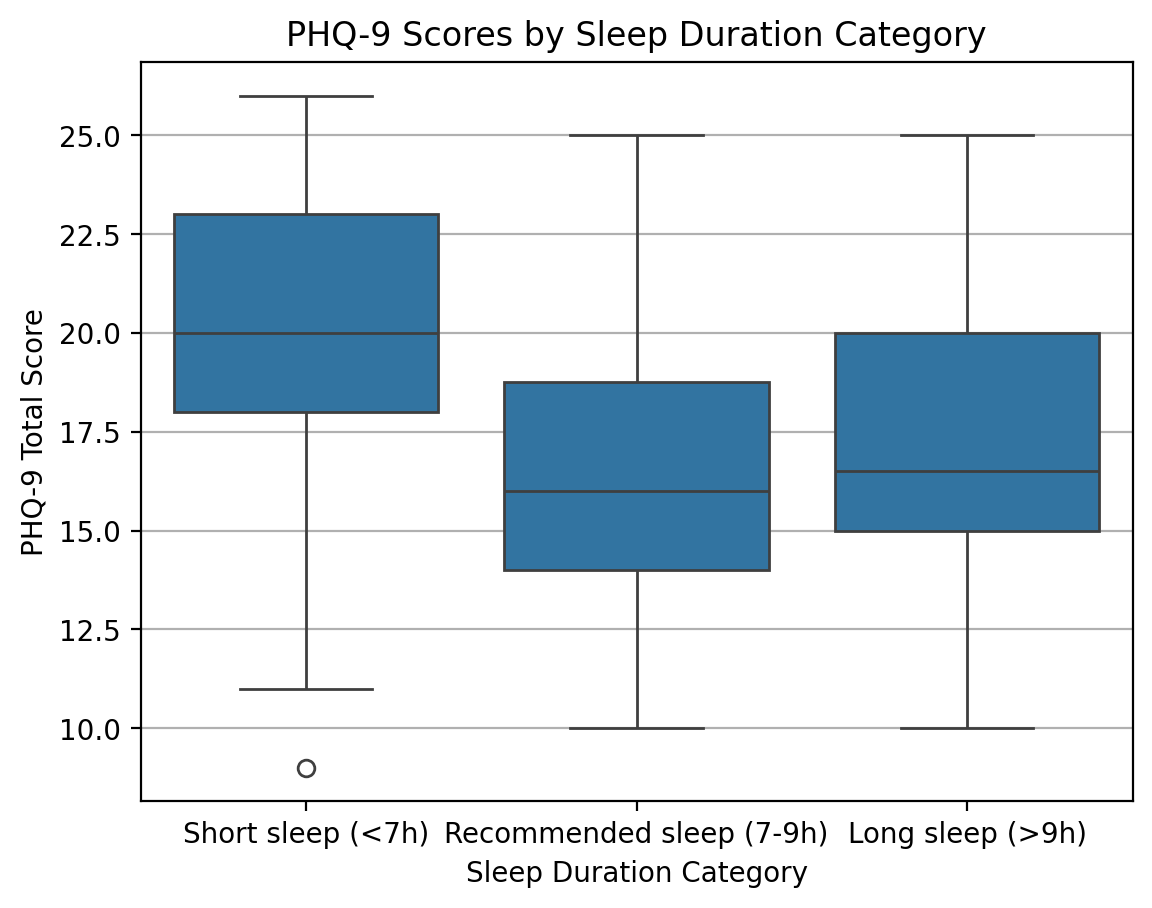

In [12]:
sns.boxplot(x="sleep_category", y="PHQ9_total", data=df)
plt.title("PHQ-9 Scores by Sleep Duration Category")
plt.xlabel("Sleep Duration Category")
plt.ylabel("PHQ-9 Total Score")
plt.grid(axis="y")
plt.show()

**Research Question 1: Is there a difference in PHQ-9 scores between short sleep and recommended sleep?**

In [13]:
short_sleep = df[df["sleep_category"] == "Short sleep (<7h)"]["PHQ9_total"]
recommended_sleep = df[df["sleep_category"] == "Recommended sleep (7-9h)"]["PHQ9_total"]

stats.mannwhitneyu(short_sleep, recommended_sleep)

MannwhitneyuResult(statistic=np.float64(1097.5), pvalue=np.float64(0.0017649042915588284))

A Mann-Whitney U test was used to compare PHQ-9 total scores between adults with short sleep and adults with recommended sleep. This test was used because PHQ-9 total score is a continuous variable and did not appear normally distributed. The p-value was 0.0018, which is below the 0.05 significance level. Therefore, there was enough evidence to show a significant difference in PHQ-9 scores between the two sleep groups.

**Research Question 2: Is sleep category associated with PHQ-9 scores of 10 or higher?**

In [14]:
# Create contingency table

contingency_table = pd.crosstab(df["sleep_category"], df["PHQ9_high"])

contingency_table

PHQ9_high,0,1
sleep_category,,
Short sleep (<7h),1,40
Recommended sleep (7-9h),0,38
Long sleep (>9h),0,26


In [15]:
# Chi-square test of independence

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 1.575984990619137
p-value: 0.45475680596418444


A chi-square test of independence was used to determine whether sleep category was associated with PHQ-9 ≥ 10 status. Both variables were categorical, making the chi-square test appropriate for this analysis. The p-value was 0.455, which is greater than the 0.05 significance level. Therefore, there was not enough evidence to conclude that sleep category was associated with having a PHQ-9 score of 10 or higher.

**Modeling**

In [19]:
linear_model = smf.ols(
    "PHQ9_total ~ C(sleep_category) + Age + Sex + Income_Poverty_Ratio",
    data=df
).fit()

linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             PHQ9_total   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     2.664
Date:                Sat, 09 May 2026   Prob (F-statistic):             0.0265
Time:                        02:00:20   Log-Likelihood:                -295.55
No. Observations:                 105   AIC:                             603.1
Df Residuals:                      99   BIC:                             619.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                        17.7195      1.817      9.751      0.000      14.114      21.325
C(sleep_category)[T.Recommended sleep (7-9h)]    -2.8182      0.945     -2.983      0.004      -4.693      -0.944
C(sleep_category)[T.Long sleep (>9h)]            -2.1365      1.059     -2.018      0.046      -4.238      -0.035
Age                                               0.0180      0.021      0.840      0.403      -0.025       0.061
Sex                                               0.9682      0.825      1.174      0.243      -0.668       2.605
Income_Poverty_Ratio                             -0.2690      0.289     -0.929      0.355      -0.843       0.305
==============================================================================
Omnibus:                        1.839   Durbin-Watson:                   1.966
Prob(Omnibus):                  0.399   Jarque-Bera (JB):                1.417
Skew:                          -0.071   Prob(JB):                        0.492
Kurtosis:                       2.449   Cond. No.                         228.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The linear regression model examined whether sleep category predicted PHQ-9 total score while adjusting for age, sex, and income-to-poverty ratio. Short sleep was used as the reference group in the model. The results showed that both recommended sleep and long sleep were associated with significantly better PHQ-9 scores compared to short sleep, based on the p-values in the regression output. This suggests that adults who slept 7–9 hours or more than 9 hours had lower depressive symptom severity than adults who slept less than 7 hours after controlling for demographic variables.

**Results**
Descriptive Statistics

In [ ]:
df.describe()

,SEQN,RIDAGEYR,RIAGENDR,INDFMPIR,SLD012,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,PHQ9_total,PHQ9_high
count,105.000000,105.000000,105.000000,1.050000e+02,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,136206.295238,42.742857,1.580952,2.180095e+00,7.338095,2.066667,2.161905,2.314286,2.209524,1.933333,2.200000,1.914286,1.666667,1.419048,17.885714,0.990476
std,3331.134151,19.380317,0.495770,1.453997e+00,2.261185,0.811772,0.810078,0.824088,0.792940,0.835126,0.848075,0.821751,0.816497,0.632166,4.321935,0.097590
min,130391.000000,18.000000,1.000000,5.397605e-79,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.000000,0.000000
25%,133524.000000,26.000000,1.000000,9.600000e-01,6.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.000000,1.000000
50%,136333.000000,43.000000,2.000000,1.870000e+00,7.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,18.000000,1.000000
75%,139179.000000,61.000000,2.000000,3.020000e+00,8.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,2.000000,21.000000,1.000000
max,142269.000000,80.000000,2.000000,5.000000e+00,14.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,26.000000,1.000000


- Sample size: 105
- Mean age: 42.7 years
- Mean sleep duration: 7.34 hours
- Mean PHQ-9 score: 17.89

In [ ]:
df.groupby("sleep_category")["PHQ9_high"].mean()*100

/tmp/ipykernel_10500/3608659372.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sleep_category")["PHQ9_high"].mean()*100


,PHQ9_high
sleep_category,
Short sleep (<7h),97.560976
Recommended sleep (7-9h),100.000000
Long sleep (>9h),100.000000


- Short sleep: 97.6%
- Recommended sleep: 100%
- Long sleep: 100%

**Discussion**

The relationship between sleep duration and depressed symptoms in adult Americans was investigated in this study. The idea is partially supported by the findings. While there was no significant correlation between sleep category and PHQ-9 ≥ 10, there was a significant difference in PHQ-9 scores between sleep groups.

One explanation could be that it was challenging to identify variations in the binary outcome because depressive symptoms were already common throughout the sample. This implies that rather than whether a person satisfies the criteria for depression, sleep length may have an impact on the intensity of symptoms.

The results are in line with earlier studies that demonstrated a connection between mental health and sleep. However, this study is unable to establish causation due to its cross-sectional design.

Self-reported sleep data, a small sample size, and a lack of survey weighting are among the limitations.

**Conclusion**

According to this study, sleep duration is linked to variations in the intensity of depressive symptoms but not to the chance of reaching the PHQ-9 criteria for depression. Future studies should use larger, longer-term datasets to further investigate the association between sleep and mental health.

**References**

1. [Brody DJ, Hughes JP.](https://https://www.cdc.gov/nchs/products/databriefs/db527.htm)

2. [lKroenke K et al.](https://https://pmc.ncbi.nlm.nih.gov/articles/PMC1495268/)

3. [CDC NHANES 2021-2023 documentation](https://https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2021-2023)

4. [CDC NHANES 2021-2023 Statistics](https://https://wwwn.cdc.gov/nchs/nhanes/search/datapage.aspx?Component=Questionnaire)

5. [Lu Dong](https://https://www.sciencedirect.com/science/article/pii/S016503272101034X)

